In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
import seaborn as sns
from behavioral_analysis.frame_pipeline.notebook_funcs import show_frame_in_notebook
from behavioral_analysis.utility.builtin_classes.objects import load_object
from sklearn.metrics import f1_score

In [2]:
# plotting parameters

sns.set_theme(style="white")

SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rcParams["ps.fonttype"] = 42  # set type 42 (truetype) fonts for ps, instead of type 3
plt.rcParams["pdf.fonttype"] = 42  # set type 42 (truetype) fonts for pdf, instead of type 3
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE, title_fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

plt.rc("lines", markersize=2, linewidth=1)
plt.rc("axes", linewidth=0.5)

plt.rc("xtick", bottom=True)
plt.rcParams["xtick.major.size"] = 3
plt.rcParams["xtick.major.width"] = 0.5
plt.rc("ytick", left=True)
plt.rcParams["ytick.major.size"] = 3
plt.rcParams["ytick.major.width"] = 0.5

default_dpi = 300

In [3]:
def vector_df_to_expected_label_series(vector_df_or_predicted_label_series):
    X = vector_df_or_predicted_label_series.copy()
    y = X.index.to_frame()[["treatment", "uniform_dosage_term"]].apply(tuple, axis=1)
    return y

In [4]:
segmenter_order2 = ["Scalars", "MoSeq"]
selected_classifiers = ["Logistic Regression", "Support Vector", "Linear Discriminant Analysis"]

segmenter_cmap = sns.color_palette("colorblind", n_colors=len(segmenter_order2))
segmenter_cmap_dict = {k: segmenter_cmap[i] for i, k in enumerate(segmenter_order2)}

root_dir = pathlib.Path(r"H:\2026_Letter")

data_dir = root_dir / "data"
code_root_dir = root_dir / "code"
image_dir = pathlib.Path("./images")
data_output_dir = code_root_dir / "data_output"

# Wiltschko 2020 Figure 4b

In [5]:
known_point_dict = {
    0.0: (195, 659),
    0.8: (195, 144)
}

unknown_points = [
    (341, 605),
    (396, 474),
    (636, 514),
    (691, 215),
    (937, 529),
    (993, 315)
]

y_value_ratio = (144 - 659) / (0.8 - 0)
def _y_to_value(y):
    return (y - 659) / y_value_ratio

unknown_point_dict = {_y_to_value(v[1]): v for v in unknown_points}
unknown_point_dict

{0.08388349514563107: (341, 605),
 0.287378640776699: (396, 474),
 0.22524271844660193: (636, 514),
 0.6897087378640777: (691, 215),
 0.20194174757281552: (937, 529),
 0.534368932038835: (993, 315)}

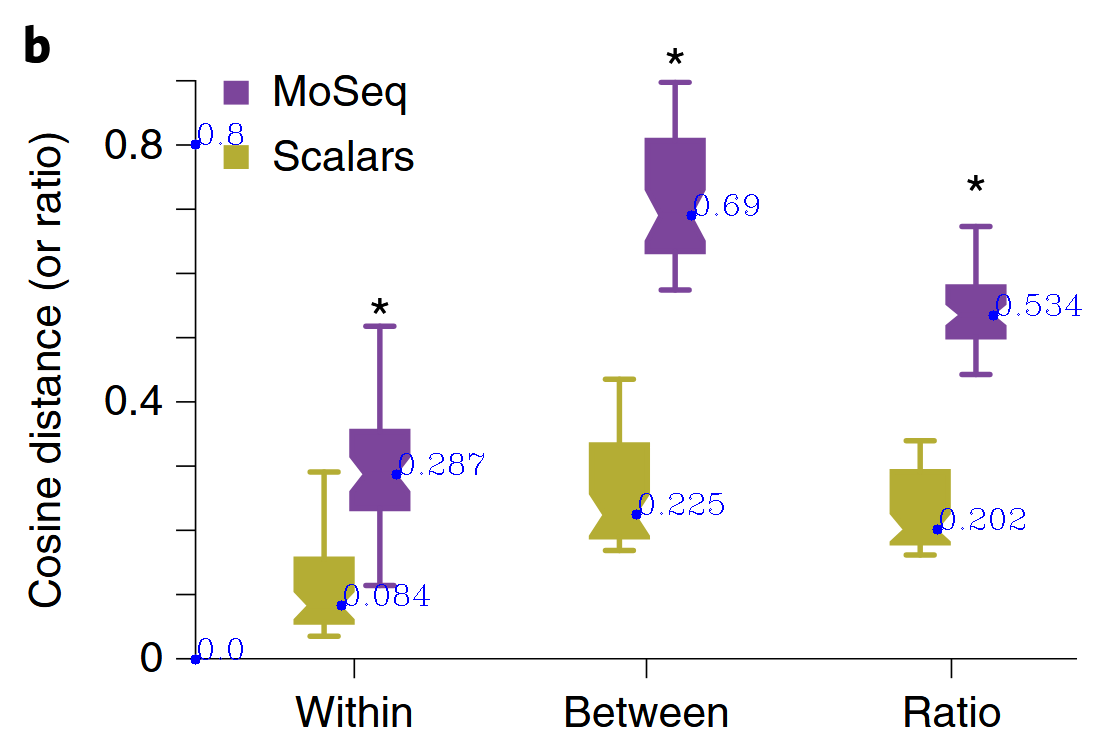

In [6]:
frame = cv2.imread(image_dir / "Wiltschko2020Fig4PanelB.png")

def _mark_value(frame, position, text, **kwargs):
    default_marker_kwargs = dict(color=(255, 0, 0))
    marker_kwargs = {**default_marker_kwargs, **kwargs}

    frame_copy = frame.copy()
    cv2.circle(frame_copy, position, radius=5, thickness=-1, **marker_kwargs)
    cv2.putText(frame_copy, text, position, fontFace=cv2.FONT_HERSHEY_COMPLEX, fontScale=1.0, **marker_kwargs)
    return frame_copy

for value, position in known_point_dict.items():
    frame = _mark_value(frame, position, str(value)) 

for value, position in unknown_point_dict.items():
    frame = _mark_value(frame, position, str(round(value, 3))) 

show_frame_in_notebook(frame)

In [7]:
# Reproduction of Scalar Within-Group and Between-Group distances shown in Wiltschko et al.
print("SCALARS")
print("expected:", 0.202)
print("methods:", 0.084 / (0.225 + 1))  # formula shown in Wiltschko et al.: Within / (Between + 1)
print("inverted:", 0.225 / (0.084 + 1))  # suspected invertion of elements

SCALARS
expected: 0.202
methods: 0.06857142857142857
inverted: 0.20756457564575645


In [8]:
# Reproduction of MoSeq Within-Group and Between-Group distances shown in Wiltschko et al.
print("MOSEQ")
print("expected:", 0.534)
print("methods:", 0.287 / (0.69 + 1))  # formula shown in Wiltschko et al.: Within / (Between + 1)
print("inverted:", 0.69 / (0.287 + 1))  # suspected invertion of elements

MOSEQ
expected: 0.534
methods: 0.16982248520710058
inverted: 0.5361305361305361


# Wiltschko 2020 Figure 3d

In [9]:
known_point_dict = {
    0.2: (115, 714),
    0.6: (115, 299)
}

unknown_points = [
    (748, 506),
    (748, 278)
]

y_value_ratio = (299 - 714) / (0.6 - 0.2)
def _y_to_value(y):
    return (y - 714) / y_value_ratio + 0.2

unknown_point_dict = {_y_to_value(v[1]): v for v in unknown_points}
unknown_point_dict

{0.40048192771084334: (748, 506), 0.6202409638554217: (748, 278)}

In [10]:
frame = cv2.imread(image_dir / "Wiltschko2020Fig3PanelD.png")

for value, position in known_point_dict.items():
    frame = _mark_value(frame, position, str(value)) 

for value, position in unknown_point_dict.items():
    frame = _mark_value(frame, position, str(round(value, 3))) 

show_frame_in_notebook(frame)

None

In [11]:
# relative gain of F1 of MoSeq over Scalar baseline, as shown in Wiltschko et al.: (MoSeqF1 - ScalarF1) / ScalarF1
(0.62 - 0.4) / 0.4

0.5499999999999999

# Measurement of F1 in our analysis

In [12]:
classifier_rename_dict = dict(
    NC_Manhattan="Nearest Centroid", 
    DecisionTree="Decision Tree", 
    KNeighbors="K-Nearest Neighbors", 
    LDA="Linear Discriminant Analysis", 
    LogReg_Optimized="Logistic Regression",
    NaiveBayes="Naive Bayes",
    Perceptron="Perceptron",
    RandomForest="Random Forest",
    Ridge="Ridge",
    SVC="Support Vector"
    )

cross_val_prediction_dict = load_object(data_output_dir / "cross_val_prediction_dict.pkl")
cross_val_prediction_series = pd.concat(cross_val_prediction_dict, names=["approach", "classifier", "cross_validation"])
_idx = cross_val_prediction_series.index.to_frame()
_idx["segmenter"] = _idx["segmenter"].apply(dict(scalars="Scalars", moseq="MoSeq").get)
_idx["classifier"] = _idx["classifier"].apply(classifier_rename_dict.get)
cross_val_prediction_series.index = pd.MultiIndex.from_frame(_idx)
cross_val_prediction_series

approach  classifier           cross_validation  segmenter  phase     treatment  uniform_dosage_term  treatment_mouse_id
density   K-Nearest Neighbors  LOO               MoSeq      Solitary  bupropion  high                 10                    (methylphenidate, low)
                                                                                                      11                    (methylphenidate, low)
                                                                                                      12                    (methylphenidate, low)
                                                                                                      1                          (bupropion, high)
                                                                                                      2                          (bupropion, high)
                                                                                                                                     ...        

In [13]:
expected_drug_label_series = vector_df_to_expected_label_series(cross_val_prediction_series).apply(lambda x: x[0]).sort_index()
predicted_drug_label_series = cross_val_prediction_series.apply(lambda x: x[0]).sort_index()

f1_series = predicted_drug_label_series.groupby(["approach", "classifier", "cross_validation", "segmenter", "phase"]).apply(lambda x: f1_score(x, expected_drug_label_series.loc[x.name], average="weighted")).rename("f1_weighted")
f1_series

approach      classifier                    cross_validation  segmenter  phase   
density       Decision Tree                 LOO               MoSeq      Solitary    0.522197
                                                              Scalars    Solitary    0.421601
              K-Nearest Neighbors           LOO               MoSeq      Solitary    0.618038
                                                              Scalars    Solitary    0.479148
              Linear Discriminant Analysis  LOO               MoSeq      Solitary    0.686480
                                                                                       ...   
rescaled_pca  Random Forest                 LOO               Scalars    Solitary    0.511467
              Ridge                         LOO               MoSeq      Solitary    0.605288
                                                              Scalars    Solitary    0.480505
              Support Vector                LOO               MoSeq     

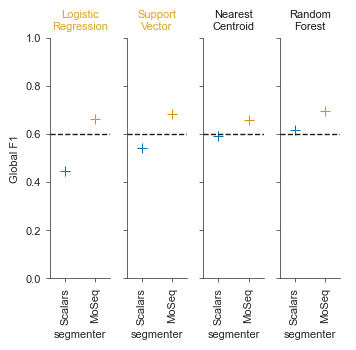

In [14]:
figsize_cm=(9, 9)
figsize = [x/2.54 for x in figsize_cm]

fg = sns.FacetGrid(f1_series.loc["raw"].reset_index(), col="classifier", col_order=["Logistic Regression", "Support Vector", "Nearest Centroid", "Random Forest"], margin_titles=True)

fg.map_dataframe(sns.pointplot, x="segmenter", y="f1_weighted", order=segmenter_order2, ls="--", lw=1, ms=7, marker="+", hue="segmenter", palette=segmenter_cmap_dict)
fg.tick_params("x", rotation=90)
fg.set_titles(row_template="{row_name}", col_template="{col_name}")
fg.add_legend()
fg.set(ylim=[0,1], xlim=[-0.5, 1.5], xticks=[0, 1])
fg.refline(y=0.6, ls="--", c="k")
fg.set_ylabels("Global F1")

for ax in fg.axes.flatten():
    title_text = ax.get_title()
    ax.set_title(title_text.replace(" ", "\n"), c="goldenrod" if title_text in selected_classifiers else "k")

fg.figure.set_size_inches(figsize)
fg.figure.tight_layout()
fg.figure.savefig(image_dir / "Fig3F1Selection.png", dpi=default_dpi)

In [15]:
known_point_dict = {
    0.0: (156, 840),
    1.0: (156, 119)
}

unknown_points = [
    (201, 519),
    (292, 362),
    (431, 450),
    (522, 348),
    (661, 414),
    (752, 366),
    (891, 396),
    (982, 338)
]

y_value_ratio = (119 - 840) / (1.0 - 0.0)
def _y_to_value(y):
    return (y - 840) / y_value_ratio

unknown_point_dict = {_y_to_value(v[1]): v for v in unknown_points}

col_order = ["Logistic Regression", "Support Vector", "Nearest Centroid", "Random Forest"]
moseq_f1s = list(unknown_point_dict.keys())[1::2]
scalar_f1s = list(unknown_point_dict.keys())[::2]
f1_diffs = np.array(moseq_f1s) - np.array(scalar_f1s)
for c, f1_d in zip(col_order, f1_diffs):
    print(c, f1_d)

Logistic Regression 0.21775312066574204
Support Vector 0.1414701803051318
Nearest Centroid 0.06657420249653268
Random Forest 0.08044382801664363


In [16]:
# Relative change in MoSeq F1 gain (MoSeqF1 - ScalarF1) of selecting Nearest Centroid over Logistic Regression: (NearestCentroidF1Gain - LogisticRegressionF1Gain) / LogisticRegressionF1Gain. ~70% Reduction
(0.06657420249653268 - 0.21775312066574204) / 0.21775312066574204

-0.6942675159235665

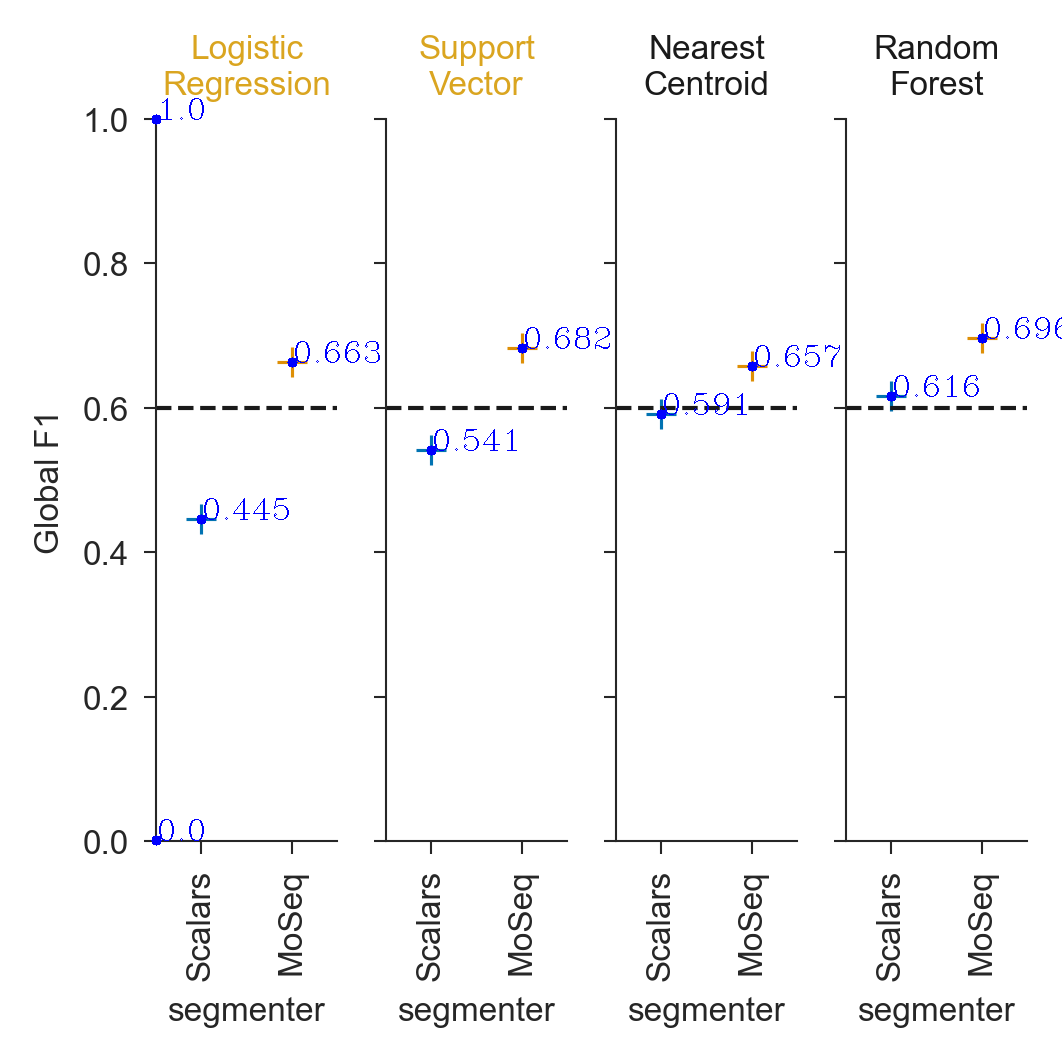

In [17]:
frame = cv2.imread(image_dir / "Fig3F1Selection.png")

for value, position in known_point_dict.items():
    frame = _mark_value(frame, position, str(value)) 

for value, position in unknown_point_dict.items():
    frame = _mark_value(frame, position, str(round(value, 3))) 

show_frame_in_notebook(frame)

In [18]:
# Reproduced relative gain of F1 of MoSeq over Scalar baseline, using Logistic Regression as shown in Wiltschko et al.: (MoSeqF1 - ScalarF1) / ScalarF1
(0.663 - 0.445) / 0.445

0.4898876404494383

In [19]:
# Relative gain of F1 of MoSeq over Scalar baseline, using Nearest Centroid Classifier instead of Logistic Regression
(0.657 - 0.591) / 0.591

0.1116751269035534